# Benchmarks

Data Source: https://github.com/blof/LINERLIB

In [1]:
from pprint import pprint

import pandas as pd

import cma
import test_benchmarks_utils as benchutils
from test_benchmarks_utils import \
	read_vessel_class_data, \
	read_port_data, \
	read_demand

In [2]:
pacific = [
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore',
	'Brunei', 'Timor-Leste',
	'China', 'Japan', 'South Korea', 'North Korea',
	'Canada', 'Mexico',
	'Fiji', 'Australia'
]
_, cma_portpool = cma.read_port_data()

In [3]:
vessel_pool = read_vessel_class_data()
portpool = read_port_data(vessel_pool, cma_portpool)

In [4]:
vessel_pool

     Vessel Type  Vessel Number
0  Rank 1 Vessel             12
1  Rank 2 Vessel             24
2  Rank 3 Vessel             22
3  Rank 4 Vessel             42
4  Rank 5 Vessel              0
5  Rank 6 Vessel              0

In [5]:
vessel_pool.get_bukering_cost_middle()

[np.float64(10885.2),
 np.float64(13722.3),
 np.float64(30397.5),
 np.float64(33234.6),
 np.float64(47593.8),
 np.float64(73475.1)]

In [6]:
portpool.get_number_of_ports()

435

In Total  134  ports are plotted


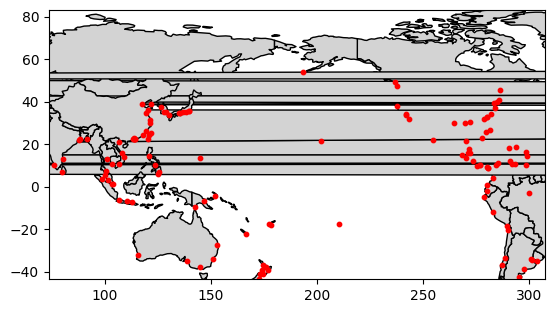

In [7]:
_, _, portpool_Pacific = portpool.plot(pacific, center_pacific=True)

In [8]:
week_demands, unit_revenue = read_demand(portpool_Pacific)
dist_mat = cma.read_sailing_distance_data(portpool_Pacific)

In [9]:
# create a new pool of ports with richer information
portgraph = cma.PortGraph(portpool_Pacific, dist_mat, week_demands, unit_revenue)
num_ports = portgraph.get_number_of_ports()
print(f'In total {num_ports} have freight demand')
portgraph

In total 45 have freight demand


[CNLYG, JPSMZ, VNHPH, USHNL, CAVAN, USOAK, SVAQJ, THLCH, MYPEN, IDSRG, USSEA, VNSGN, KRPUS, GUGUM, USLGB, CNDLC, MYPKG, IDSUB, TWKEL, MXLZC, JPNGO, USLAX, TWKHH, CNXMN, JPTYO, NICIO, JPUKB, PHGES, IDJKT, CNTAO, MYTPP, JPOSA, PHMNL, USDUT, PABLB, CNYTN, CNFOC, HKHKG, JPYOK, PAMIT, JPHKT, MXESE, VNDAD, CNSHA, SGSIN]

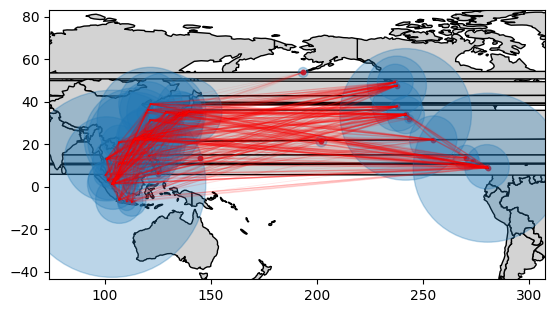

In [10]:
# plot the demands between ports
_, ax, _ = portgraph.plot(pacific, center_pacific=True)

In [11]:
from cma import ServiceGraph, create_service_line

line_1 = create_service_line('line 1', benchutils.line_1_idlst, portpool)
line_2 = create_service_line('line 2', benchutils.line_2_idlst, portpool)
line_3 = create_service_line('line 3', benchutils.line_3_idlst, portpool)
line_4 = create_service_line('line 4', benchutils.line_4_idlst, portpool)
line_5 = create_service_line('line 5', benchutils.line_5_idlst, portpool)
line_6 = create_service_line('line 6', benchutils.line_6_idlst, portpool)
line_7 = create_service_line('line 7', benchutils.line_7_idlst, portpool)
line_8 = create_service_line('line 8', benchutils.line_8_idlst, portpool)
line_9 = create_service_line('line 9', benchutils.line_9_idlst, portpool)
line_10 = create_service_line('line 10', benchutils.line_10_idlst, portpool)
line_11 = create_service_line('line 11', benchutils.line_11_idlst, portpool)
line_12 = create_service_line('line 12', benchutils.line_12_idlst, portpool)
line_13 = create_service_line('line 13', benchutils.line_13_idlst, portpool)
line_14 = create_service_line('line 14', benchutils.line_14_idlst, portpool)
line_15 = create_service_line('line 15', benchutils.line_15_idlst, portpool)
line_16 = create_service_line('line 16', benchutils.line_16_idlst, portpool)
line_17 = create_service_line('line 17', benchutils.line_17_idlst, portpool)

init_service_graph = ServiceGraph(
	[line_1, line_2, line_3, line_4, line_5, line_6, line_7, line_8, line_9,
	line_10, line_11, line_12, line_13, line_14, line_15, line_16, line_17])

In [12]:
# servicegraph.plot( \
# 	lines_info=[
# 		('line_1', 'firebrick'), ('line_2', 'firebrick'),
# 		('line_3', 'firebrick'), ('line_4', 'firebrick'),
# 		('line_5', 'firebrick'), ('line_6', 'firebrick'),
# 		('line_7', 'firebrick'), ('line_8', 'firebrick'),
# 		('line_9', 'firebrick'), ('line_10', 'firebrick'),
# 		('line_11', 'firebrick'), ('line_12', 'firebrick'),
# 		('line_13', 'firebrick'), ('line_14', 'firebrick'),
# 		('line_15', 'firebrick')
# 	], selected_countries=pacific,
# 	portgraph=portgraph,
# )

In [13]:
# create a week prediction model
week_predictor = cma.create_week_predictor()
week_predictor.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:               OLS              Adj. R-squared:     0.890   
Dependent Variable:  weeks            AIC:                92.3843 
Date:                2025-07-25 17:36 BIC:                103.7352
No. Observations:    49               Log-Likelihood:     -40.192 
Df Model:            5                F-statistic:        78.32   
Df Residuals:        43               Prob (F-statistic): 1.77e-20
R-squared:           0.901            Scale:              0.34412 
------------------------------------------------------------------
                     Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
------------------------------------------------------------------
const               -0.5318   0.4189 -1.2695 0.2111 -1.3767 0.3130
sailing_distance     0.0005   0.0000 13.8420 0.0000  0.0004 0.0005
stops_number         0.0549   0.0379  1.4485 0.1547 -0.0215 0.1313
ave_productivity     0.0009   0.0022  0.4213 0.6757 -0.0035 0.0053
ave_demand_inflows   0.0002   0.0001  1.7211 0.0924 -0.0000 0.0005
ave_demand_outflows  0.0001   0.0002  0.5632 0.5763 -0.0003 0.0006
------------------------------------------------------------------
Omnibus:               8.717        Durbin-Watson:           1.521
Prob(Omnibus):         0.013        Jarque-Bera (JB):        7.882
Skew:                  0.909        Prob(JB):                0.019
Kurtosis:              3.743        Condition No.:           33496
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

In [ ]:
# solve the optimal demand fulfillment
init_service_graph.solve_approximated(portgraph, vessel_pool, week_predictor, min_cost=False)
init_service_graph.total_profit()

>>> 693


/Users/zhuanglinsheng/Documents/Github/nus_cma_project/.venv/lib/python3.13/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "
